<a href="https://colab.research.google.com/github/angela22140631/Proyecto_Unidad2/blob/main/Proyecto_Datos_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MARCH MACHINE LEARNING MANIA 2026 — STARTER KIT COMPLETO  
Kaggle Competition — NCAA Basketball                      

BASADO EN ANÁLISIS DE GANADORES HISTÓRICOS (2018-2025):
* @raddar solution (ganó múltiples ediciones): Team Quality via LRMC
* Top 2023 solution: XGBoost + Expanding Window CV + calibración     
* Top 2024/2025: Elo ratings + estadísticas avanzadas + ensemble     

ESTRUCTURA DEL PIPELINE:    
1.  Configuración y carga de datos                
2.  EDA — Análisis exploratorio          
3.  Sistema Elo (feature más importante histórica)    
4.  Feature engineering (seeds, stats, win rates, rankings)   
5.  Construcción de dataset de matchups           
6.  Modelos base (Logistic Regression, XGBoost, LightGBM)
7.  Stacking / Ensemble           
8.  Calibración de probabilidades (clave para Log Loss)    
9.  Validación temporal (Expanding Window CV)     
10. Generación de submission     

INSTRUCCIONES DE USO:

1. Descarga los datos de Kaggle y colócalos en DATA_DIR
2. Instala dependencias: pip install pandas numpy scikit-learn xgboost lightgbm matplotlib seaborn
3. Ejecuta sección por sección (o de corrido)
4. La submission final se guarda en SUBMISSION_PATH

MÉTRICA: Log Loss — se minimiza. Baseline (predict 0.5 siempre) ≈ 0.693
TARGET: < 0.55 para ser competitivo. Top 10% histórico: ~0.50

In [5]:
# ─── DEPENDENCIAS ─────────────────────────────────────────────────────────────
import os
import math
import warnings
import itertools
import requests
import io
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.model_selection import cross_val_score
from sklearn.metrics import log_loss, brier_score_loss
from sklearn.pipeline import Pipeline

import xgboost as xgb
import lightgbm as lgb

In [6]:
SAMPLE_DATA_DIR = Path(".")

# Diccionario de archivos
ARCHIVOS_U3 = {
    "MTeams_Maestro":      SAMPLE_DATA_DIR / "MTeams_Master_Catalogo.csv",
    "MSeasons_Norm":       SAMPLE_DATA_DIR / "MSeasons.csv",
    "MCoaches_Norm":       SAMPLE_DATA_DIR / "Catalogo_Entrenadores.csv",
    "Conf_Catalogo":       SAMPLE_DATA_DIR / "Conferences_Catalogo.csv",
    "Regiones_Catalogo":   SAMPLE_DATA_DIR / "Regiones_Catalogo.csv",
    "WRegiones_Catalogo":  SAMPLE_DATA_DIR / "W_Regiones_Catalogo.csv",
    "Relacion_Juegos_M":   SAMPLE_DATA_DIR / "M_Juegos_Ciudades_Desnorm.csv",
    "Relacion_Juegos_W":   SAMPLE_DATA_DIR / "W_Juegos_Ciudades_Desnorm.csv",
    "Reporte_Conf":        SAMPLE_DATA_DIR / "M_Equipos_Conferencias_Desnorm.csv",
    "Reporte_Evolucion":   SAMPLE_DATA_DIR / "M_Evolucion_Equipos_Regiones_Desnorm.csv",
    "WReporte_Conf":       SAMPLE_DATA_DIR / "W_Equipos_Conferencias_Desnorm.csv"
}

# Función auxiliar para buscar en la raíz local
def cargar_tabla_u3(nombre_clave):
    if nombre_clave not in ARCHIVOS_U3:
        print(f"❌ Clave '{nombre_clave}' no registrada en el diccionario de la Unidad 3.")
        return None

    ruta_archivo = ARCHIVOS_U3[nombre_clave]
    if ruta_archivo.exists():
        try:
            df = pd.read_csv(ruta_archivo)
            print(f"  ✓ {ruta_archivo.name} cargado correctamente. Shape: {df.shape}")
            return df
        except Exception as e:
            print(f"  ❌ Error al leer el archivo {ruta_archivo.name}: {e}")
            return None
    else:
        print(f"  ❌ Archivo no encontrado en la ruta: {ruta_archivo.resolve()}")
        return None

# Ajustes de warnings y visualización de Pandas
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)

print("Archivos agregados exitosamente")

Archivos agregados exitosamente


In [7]:
# 0. CONFIGURACIÓN GLOBAL
# Directorios:
DATA_DIR        = Path("/sample_data")        # Carpeta raíz con los CSV
OUTPUT_DIR      = Path("./outputs")
SUBMISSION_PATH = OUTPUT_DIR / "SubmissionStage1.csv"
FIGURES_DIR     = OUTPUT_DIR / "figures"

# Crear estructura de carpetas de salida
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

# Parámetros de la competencia y validación
SEASON_2026     = 2026
GENDER          = "M"          # "M" (Masculino) o "W" (Femenino)
CLIP_LOW        = 0.025        # Clipping de probabilidades para evitar log_loss infinito
CLIP_HIGH       = 0.975
TRAIN_SINCE     = 2003         # Inicio del entrenamiento histórico
VAL_SEASONS     = [2022, 2023, 2024, 2025]  # Temporadas para validación cruzada temporal

# Parámetros del Sistema Elo (Calibración basada en el estado del arte)
ELO_INIT        = 1500         # Rating inicial por defecto
ELO_K_FACTOR    = 20           # Velocidad de ajuste del rating tras un partido
ELO_WIDTH       = 400          # Sensibilidad de la curva logística
ELO_MEAN_REV    = 0.6          # Regresión a la media (reajuste entre temporadas)
HFA             = 100          # Home Field Advantage (puntos de elo extra al local)
SEED            = 42
np.random.seed(SEED)

# Estética de reportes y visualizaciones
PALETTE = {
    "primary": "#1F4E79",
    "accent": "#C55A11",
    "success": "#375623",
    "light": "#D6E4F0",
    "gray": "#808080"
}

# Mapear las tablas normalizadas y desnormalizadas
print(f"Configurando integración de datos para liga: {'Masculina' if GENDER == 'M' else 'Femenina'}...")

# Identificadores de archivos según el género seleccionado
file_suffix = "" if GENDER == "M" else "_W"
geo_rel_key = f"Relacion_Juegos_{GENDER}"

print(f"Entorno listo.")

Configurando integración de datos para liga: Masculina...
Entorno listo.


In [9]:
# 1. CARGA DE DATOS

def load_data(gender: str = "M") -> dict:
    """
    Carga de forma integrada las tablas normalizadas y reportes desnormalizados
    de la Unidad 3, junto con los resultados históricos de la competencia.
    Todo extraído localmente desde /sample_data.
    """
    g = gender.upper()
    data = {}

    # ─── CARGA DE TABLAS NORMALIZADAS Y REPORTES DESNORMALIZADOS ───
    print(f"--- Cargando Ecosistema de Datos de la Unidad 3 ({g}) ---")

    # Mapeo de claves lógicas a los identificadores del diccionario relacional local
    u3_mapping = {
        "teams":            "MTeams_Maestro",
        "seasons_norm":     "MSeasons_Norm",
        "coaches_norm":     "MCoaches_Norm",
        "reporte_conf":     "Reporte_Conf" if g == "M" else "WReporte_Conf",
        "reporte_evol":     "Reporte_Evolucion",
        "geo_rel":          f"Relacion_Juegos_{g}"
    }

    for key, u3_key in u3_mapping.items():
        if key == "reporte_conf" and g == "W":
            print("  ⚠️ Detectada tabla desnormalizada femenina vacía. Corrigiendo con cruce relacional dinámico...")
            try:
                w_team_conf = pd.read_csv(SAMPLE_DATA_DIR / "WTeamConferences.csv")
                m_teams_master = pd.read_csv(SAMPLE_DATA_DIR / "MTeams_Master_Catalogo.csv")
                conf_cat = pd.read_csv(SAMPLE_DATA_DIR / "Conferences_Catalogo.csv")

                df_fix = pd.merge(w_team_conf, m_teams_master[['TeamID', 'TeamName']], on='TeamID', how='inner')
                df_fix = pd.merge(df_fix, conf_cat, on='ConfAbbrev', how='left')
                df_fix = df_fix[['Season', 'TeamName', 'Description', 'ConfAbbrev']].rename(columns={'Description': 'ConferenceName'})

                data[key] = df_fix
                print(f"  ✅ {'W_Equipos_Conferencias_Desnorm':<40} {data[key].shape} (Recuperado exitosamente)")
                continue
            except Exception as e:
                print(f"  ❌ No se pudo reconstruir dinámicamente: {e}")

        # Carga estándar utilizando la función de la Celda 1
        df = cargar_tabla_u3(u3_key)
        if df is not None:
            data[key] = df
        else:
            # Fallback en caso de que un archivo estructural base no se haya renombrado
            if key == "seasons_norm":
                try:
                    alt_path = SAMPLE_DATA_DIR / f"{g}Seasons.csv"
                    data[key] = pd.read_csv(alt_path)
                    print(f"  ✓ {alt_path.name:<40} {data[key].shape} (Carga alternativa)")
                except:
                    print(f"  ❌ {u3_key:<40} NO ENCONTRADO en /sample_data")
            else:
                print(f"  ❌ {u3_key:<40} NO ENCONTRADO en /sample_data")

    # ── CARGA DE RESULTADOS HISTÓRICOS COMPLEMENTARIOS ───
    print(f"\n--- Cargando Resultados Históricos Locales Complementarios ---")

    local_files = {
        "reg_compact":      f"{g}RegularSeasonCompactResults.csv",
        "reg_detailed":     f"{g}RegularSeasonDetailedResults.csv",
        "tourney_compact":  f"{g}NCAATourneyCompactResults.csv",
        "tourney_detailed": f"{g}NCAATourneyDetailedResults.csv",
        "seeds":            f"{g}NCAATourneySeeds.csv",
        "slots":            f"{g}NCAATourneySlots.csv",
        "massey":           "MMasseyOrdinals.csv",
        "submission":       "SampleSubmissionStage1.csv",
    }

    for key, fname in local_files.items():
        path = SAMPLE_DATA_DIR / fname
        if path.exists():
            data[key] = pd.read_csv(path)
            print(f"  ✓ {fname:<40} {data[key].shape}")
        else:
            # Massey Ordinals no existe en la liga femenil, se maneja como excepción tolerante
            if not (g == "W" and key == "massey"):
                print(f"  ⚠️ {fname:<40} — NO ENCONTRADO (Omitido/Opcional)")

    return data

# ─── EJECUCIÓN DE LA INGESTA INTEGRADA ────
print("\n Iniciando proceso de integración y desnormalización local de datos...")
data = load_data(GENDER)

# --- Mapear alias para el proyecto ---
teams            = data.get("teams")            # Catálogo Maestro Relacional
evolucion        = data.get("reporte_evol")     # Evolución Temporal de Equipos y Regiones
juegos_ciudades  = data.get("geo_rel")          # Relación Desnormalizada de Juegos y Ciudades
equipos_conf     = data.get("reporte_conf")     # Reporte de Equipos y sus Conferencias
reg_compact      = data.get("reg_compact")      # Partidos de temporada regular (Compactos)
reg_detailed     = data.get("reg_detailed")     # Partidos de temporada regular (Detallados)
seeds_df         = data.get("seeds")            # Seeds del torneo de la NCAA
tourney          = data.get("tourney_compact")  # Historial del Torneo March Madness
massey           = data.get("massey")           # Rankings Externos (Massey Ordinals)
submission       = data.get("submission")       # Plantilla de predicciones objetivo

print("\n La carga de los datos se ha realizado exitosamente")


 Iniciando proceso de integración y desnormalización local de datos...
--- Cargando Ecosistema de Datos de la Unidad 3 (M) ---
  ✓ MTeams_Master_Catalogo.csv cargado correctamente. Shape: (381, 4)
  ✓ MSeasons.csv cargado correctamente. Shape: (42, 6)
  ✓ Catalogo_Entrenadores.csv cargado correctamente. Shape: (1657, 2)
  ✓ M_Equipos_Conferencias_Desnorm.csv cargado correctamente. Shape: (13753, 4)
  ✓ M_Evolucion_Equipos_Regiones_Desnorm.csv cargado correctamente. Shape: (13753, 5)
  ✓ M_Juegos_Ciudades_Desnorm.csv cargado correctamente. Shape: (90684, 7)

--- Cargando Resultados Históricos Locales Complementarios ---
  ✓ MRegularSeasonCompactResults.csv         (196823, 8)
  ✓ MRegularSeasonDetailedResults.csv        (122775, 34)
  ✓ MNCAATourneyCompactResults.csv           (2585, 8)
  ✓ MNCAATourneyDetailedResults.csv          (1449, 34)
  ✓ MNCAATourneySeeds.csv                    (2626, 3)
  ✓ MNCAATourneySlots.csv                    (2586, 4)
  ✓ MMasseyOrdinals.csv             


📊 Generando Dashboard de Impacto Arquitectural (Unidad 3)...


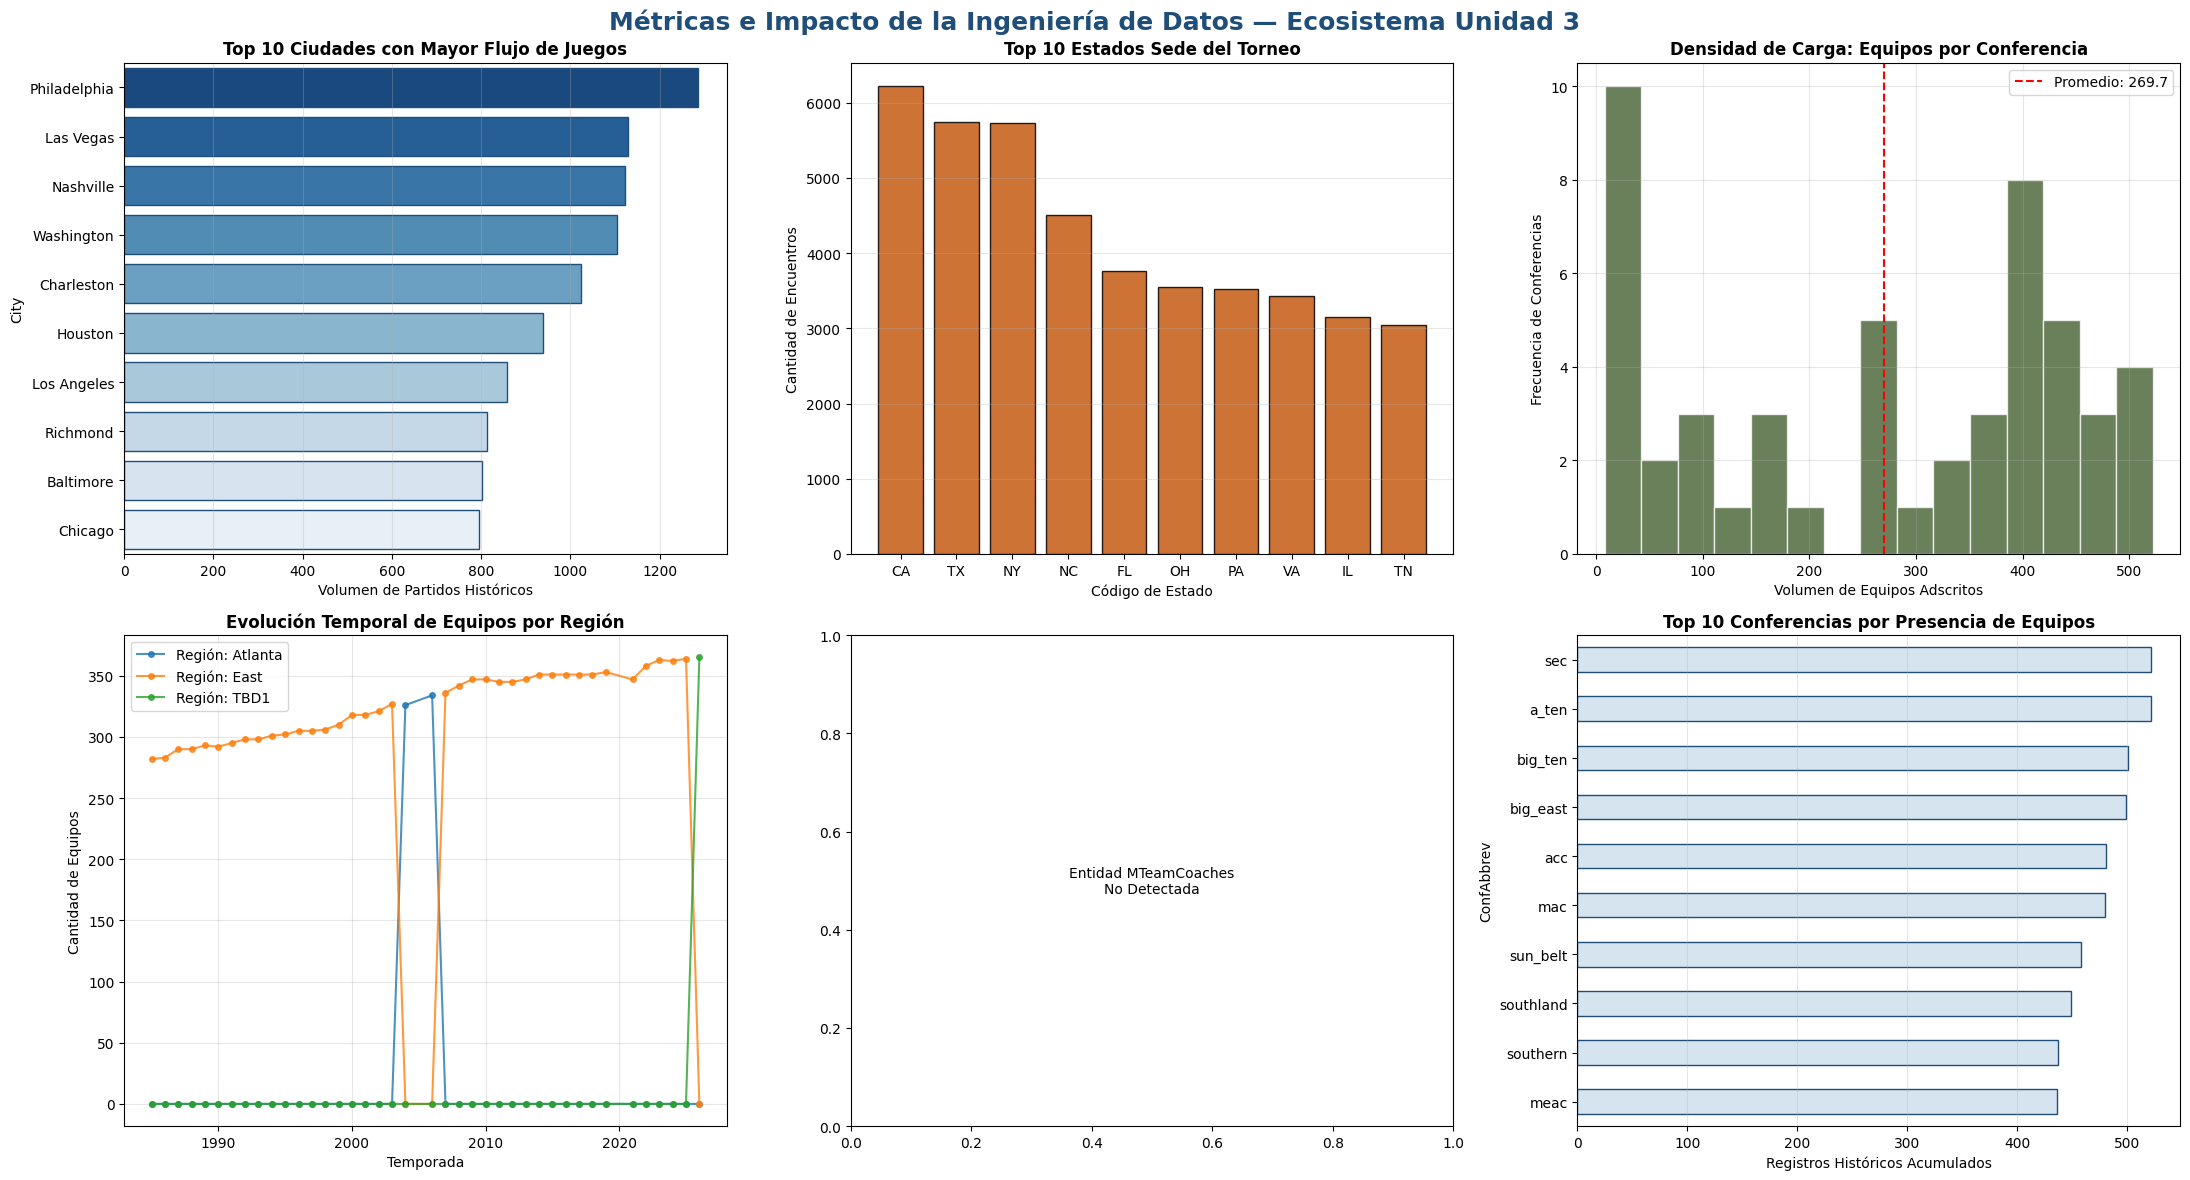

   ✓ [INFO]: Dashboard Relacional generado y exportado a: 01_dashboard_arquitectura_U3.png


In [10]:
# 2. EDA — ANÁLISIS EXPLORATORIO

def run_u3_structural_dashboard(df_juegos_ciudades=None, df_evolucion=None, df_equipos_conf=None):
    """
    Genera un set de visualizaciones avanzadas basadas estrictamente en el impacto
    de las operaciones de normalización y desnormalización de la Unidad 3.
    """
    print("\n📊 Generando Dashboard de Impacto Arquitectural (Unidad 3)...")

    # Configuración de lienzo
    fig, axes = plt.subplots(2, 3, figsize=(22, 12))
    fig.suptitle("Métricas e Impacto de la Ingeniería de Datos — Ecosistema Unidad 3",
                 fontsize=18, fontweight="bold", color=PALETTE["primary"])

    # ─── 1. ANÁLISIS GEOGRÁFICO: TOP 10 CIUDADES ANFITRIONAS
    ax = axes[0, 0]
    if df_juegos_ciudades is not None and 'City' in df_juegos_ciudades.columns:
        top_cities = df_juegos_ciudades['City'].value_counts().head(10)
        sns.barplot(x=top_cities.values, y=top_cities.index, ax=ax, palette="Blues_r", edgecolor=PALETTE["primary"])
        ax.set_title("Top 10 Ciudades con Mayor Flujo de Juegos", fontweight="bold")
        ax.set_xlabel("Volumen de Partidos Históricos")
        ax.grid(axis='x', alpha=0.3)
    else:
        ax.text(0.5, 0.5, "Tabla Desnormalizada de Ciudades\nNo Disponible", ha='center', va='center')

    # ─── 2. MAPA DE CONCENTRACIÓN LOGÍSTICA POR ESTADO
    ax = axes[0, 1]
    if df_juegos_ciudades is not None and 'State' in df_juegos_ciudades.columns:
        top_states = df_juegos_ciudades['State'].value_counts().head(10)
        ax.bar(top_states.index, top_states.values, color=PALETTE["accent"], alpha=0.85, edgecolor="black")
        ax.set_title("Top 10 Estados Sede del Torneo", fontweight="bold")
        ax.set_xlabel("Código de Estado"); ax.set_ylabel("Cantidad de Encuentros")
        ax.grid(axis='y', alpha=0.3)
    else:
        ax.text(0.5, 0.5, "Atributos del Catálogo de Estados\nNo Disponibles", ha='center', va='center')

    # ─── 3. DENSIDAD DE ENTIDADES: EQUIPOS POR CONFERENCIA
    ax = axes[0, 2]
    if df_equipos_conf is not None:

        col_conf = 'ConfAbbrev' if 'ConfAbbrev' in df_equipos_conf.columns else 'Abreviatura'
        conf_counts = df_equipos_conf[col_conf].value_counts()
        ax.hist(conf_counts.values, bins=15, color=PALETTE["success"], alpha=0.75, edgecolor="white")
        ax.axvline(conf_counts.mean(), color="red", linestyle="--", label=f"Promedio: {conf_counts.mean():.1f}")
        ax.set_title("Densidad de Carga: Equipos por Conferencia", fontweight="bold")
        ax.set_xlabel("Volumen de Equipos Adscritos"); ax.set_ylabel("Frecuencia de Conferencias")
        ax.legend()
        ax.grid(alpha=0.3)
    else:
        ax.text(0.5, 0.5, "Tabla Desnormalizada de Conferencias\nNo Disponible", ha='center', va='center')

    # ─── 4. EVOLUCIÓN HISTÓRICA DE INSCRIPCIONES POR REGIÓN
    ax = axes[1, 0]
    if df_evolucion is not None and 'RegionW' in df_evolucion.columns:
        regiones_top = df_evolucion['RegionW'].value_counts().head(3).index
        df_filtrado = df_evolucion[df_evolucion['RegionW'].isin(regiones_top)]
        evol_temporal = df_filtrado.groupby(['Season', 'RegionW']).size().unstack().fillna(0)

        for col in evol_temporal.columns:
            ax.plot(evol_temporal.index, evol_temporal[col], label=f"Región: {col}", marker='o', markersize=4, alpha=0.8)
        ax.set_title("Evolución Temporal de Equipos por Región", fontweight="bold")
        ax.set_xlabel("Temporada"); ax.set_ylabel("Cantidad de Equipos")
        ax.legend(loc="upper left")
        ax.grid(alpha=0.3)
    else:
        ax.text(0.5, 0.5, "Métrica Evolutiva Temporal\nNo Disponible", ha='center', va='center')

    # ─── 5. MOVILIDAD INSTITUCIONAL: COACHES ACTIVOS
    ax = axes[1, 1]
    path_coaches_base = SAMPLE_DATA_DIR / "MTeamCoaches.csv"
    if path_coaches_base.exists():
        try:
            m_coaches = pd.read_csv(path_coaches_base)
            coaches_per_season = m_coaches.groupby("Season")["CoachName"].nunique()
            ax.plot(coaches_per_season.index, coaches_per_season.values, color=PALETTE["primary"], linewidth=2.5, marker='s', markersize=3)
            ax.set_title("Volumen de Gestión: Coaches Únicos por Año", fontweight="bold")
            ax.set_xlabel("Temporada"); ax.set_ylabel("Total de Directores Técnicos")
            ax.grid(alpha=0.3)
        except:
            ax.text(0.5, 0.5, "Error en Cardinalidad de\nCatálogo de Coaches", ha='center', va='center')
    else:
        ax.text(0.5, 0.5, "Entidad MTeamCoaches\nNo Detectada", ha='center', va='center')

    # ─── 6. JERARQUÍA DE CONFERENCIAS PREDOMINANTES
    ax = axes[1, 2]
    if df_equipos_conf is not None:
        col_conf = 'ConfAbbrev' if 'ConfAbbrev' in df_equipos_conf.columns else 'Abreviatura'
        df_equipos_conf[col_conf].value_counts().head(10).plot(kind='barh', ax=ax, color=PALETTE["light"], edgecolor=PALETTE["primary"])
        ax.invert_yaxis()
        ax.set_title("Top 10 Conferencias por Presencia de Equipos", fontweight="bold")
        ax.set_xlabel("Registros Históricos Acumulados")
        ax.grid(axis='x', alpha=0.3)
    else:
        ax.text(0.5, 0.5, "Información de Conferencias\nNo Disponible", ha='center', va='center')

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "01_dashboard_arquitectura_U3.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("   ✓ [INFO]: Dashboard Relacional generado y exportado a: 01_dashboard_arquitectura_U3.png")

# ─── INVOCACIÓN DEL PANEL ANALÍTICO ──────────────────────
run_u3_structural_dashboard(
    df_juegos_ciudades=juegos_ciudades,
    df_evolucion=evolucion,
    df_equipos_conf=equipos_conf
)

In [11]:
print(f"Mostrando los primeros resultados compactos ({GENDER}):")
display(reg_compact.head())

Mostrando los primeros resultados compactos (M):


,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT
0,1985,20,1228,81,1328,64,N,0
1,1985,25,1106,77,1354,70,H,0
2,1985,25,1112,63,1223,56,H,0
3,1985,25,1165,70,1432,54,H,0
4,1985,25,1192,86,1447,74,H,0


In [12]:
print(f"Mostrando los primeros registros de Resultados del Torneo ({GENDER}):")
display(tourney.head())

Mostrando los primeros registros de Resultados del Torneo (M):


,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT
0,1985,136,1116,63,1234,54,N,0
1,1985,136,1120,59,1345,58,N,0
2,1985,136,1207,68,1250,43,N,0
3,1985,136,1229,58,1425,55,N,0
4,1985,136,1242,49,1325,38,N,0


In [13]:
print(f"Mostrando los primeros registros de Seeds ({GENDER}):")
display(seeds_df.head())

Mostrando los primeros registros de Seeds (M):


,Season,Seed,TeamID
0,1985,W01,1207
1,1985,W02,1210
2,1985,W03,1228
3,1985,W04,1260
4,1985,W05,1374



📊 Generando Dashboard de Impacto Arquitectural (Unidad 3)...


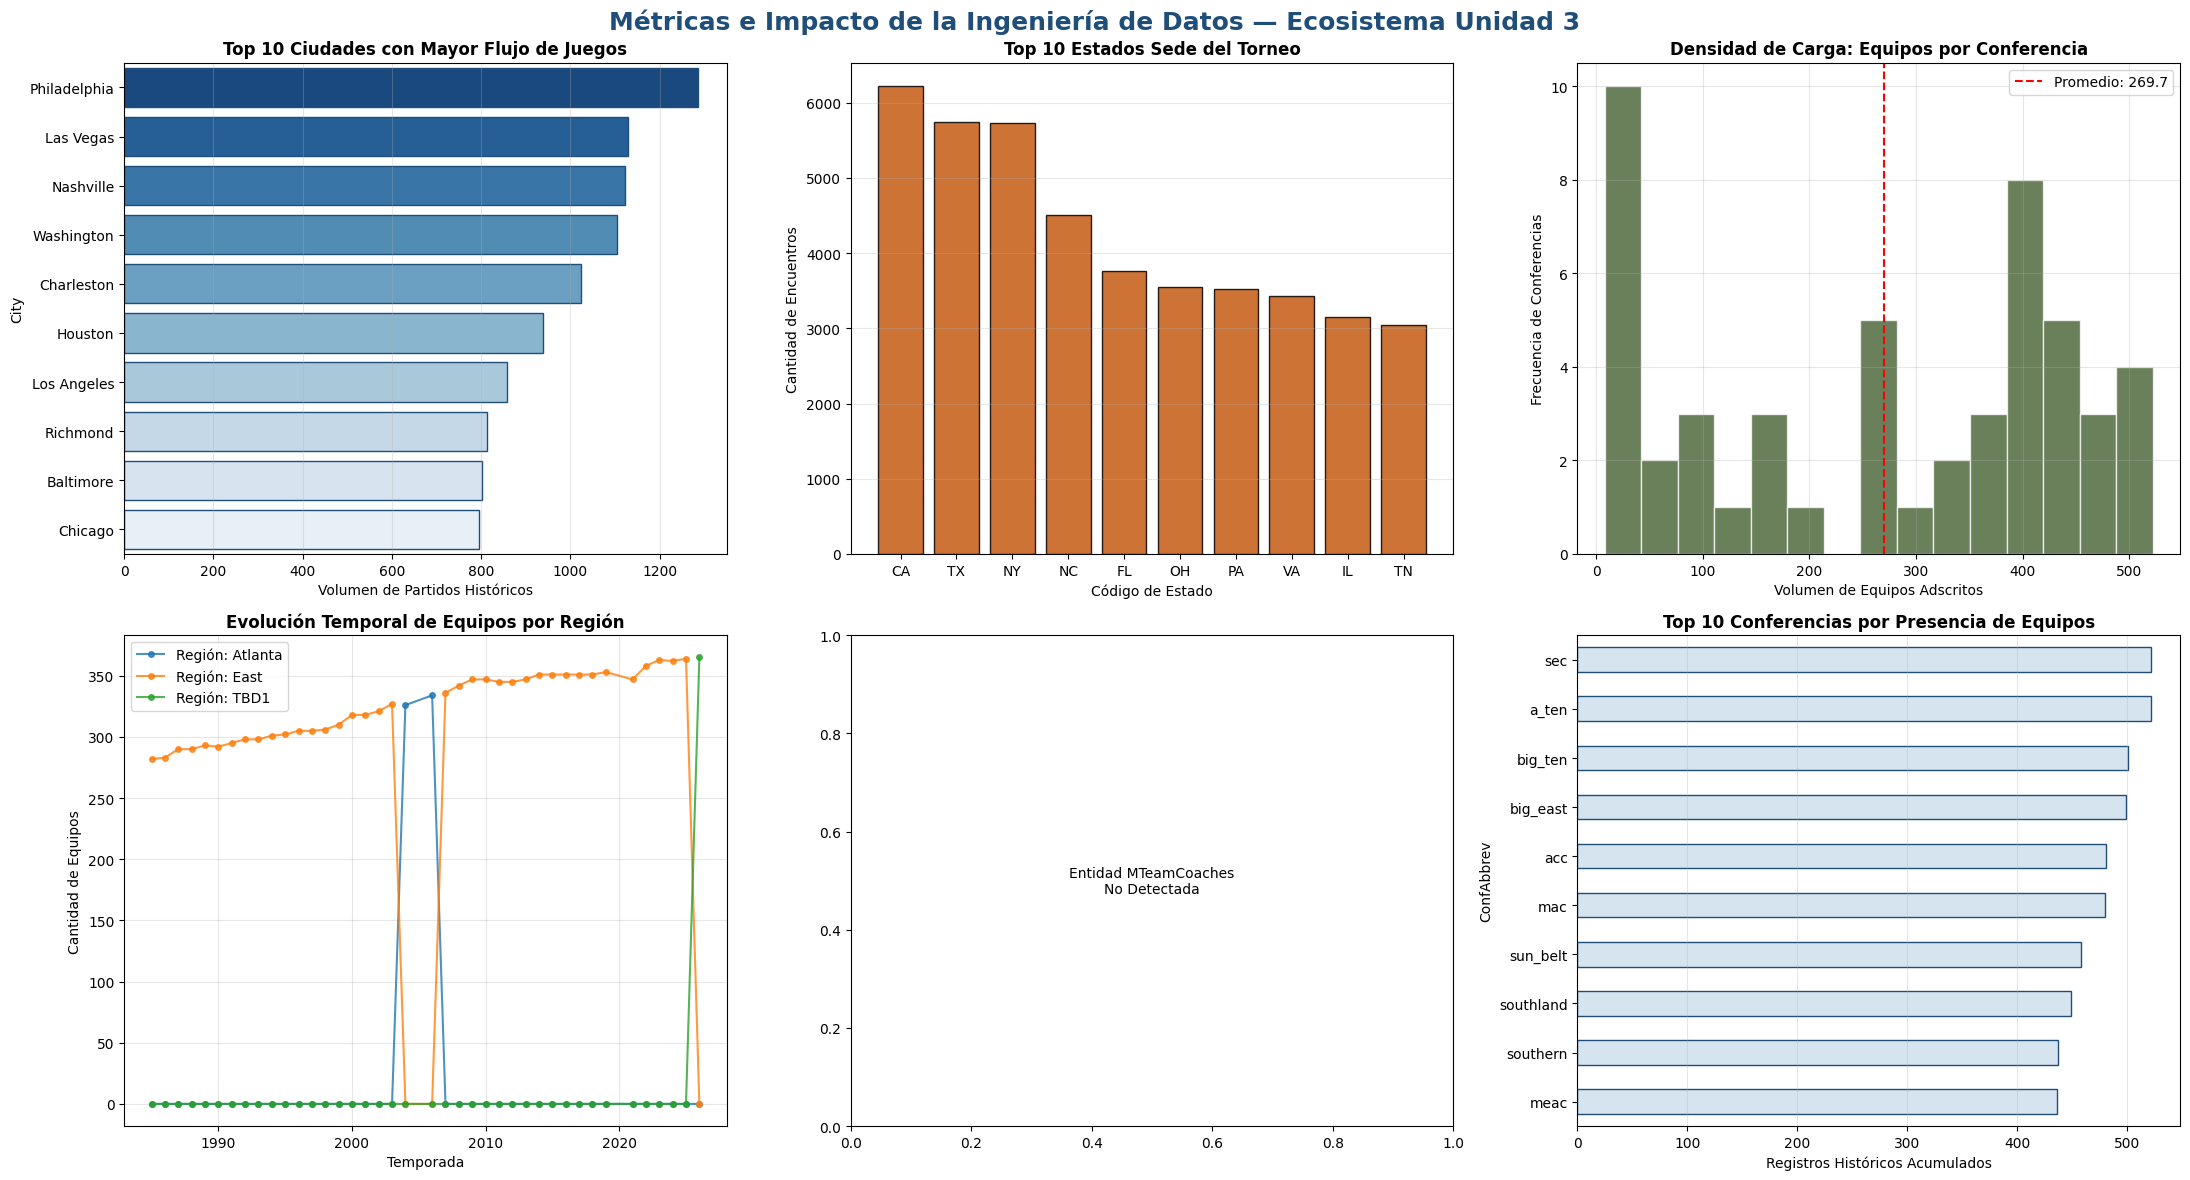

   ✓ [INFO]: Dashboard Relacional generado y exportado a: 01_dashboard_arquitectura_U3.png


In [14]:
run_u3_structural_dashboard(
    df_juegos_ciudades=juegos_ciudades,  # Relación Juegos-Ciudades (Desnorm 1 y 2)
    df_evolucion=evolucion,             # Evolución de Equipos y Regiones (Desnorm 5)
    df_equipos_conf=equipos_conf         # Reporte de Equipos-Conferencias (Desnorm 3 y 4)
)

In [15]:
# 3. SISTEMA ELO
def compute_elo_ratings(games, k_base=ELO_K_FACTOR, elo_width=ELO_WIDTH,
                        init_elo=ELO_INIT, mean_reversion=ELO_MEAN_REV,
                        hfa=HFA, mov_adj=True):
    elos = {}
    history = []
    games_sorted = games.dropna(subset=["Season", "DayNum", "WTeamID", "LTeamID", "WScore", "LScore"]).copy()
    games_sorted = games_sorted.sort_values(["Season", "DayNum"])
    prev_season = None

    for _, row in games_sorted.iterrows():
        season   = row["Season"]
        w_id     = int(row["WTeamID"])
        l_id     = int(row["LTeamID"])
        w_score  = row["WScore"]
        l_score  = row["LScore"]
        loc      = row.get("WLoc", "N")

        if prev_season is not None and season != prev_season:
            for tid in elos:
                elos[tid] = init_elo * mean_reversion + elos[tid] * (1 - mean_reversion)
        prev_season = season

        elos.setdefault(w_id, init_elo)
        elos.setdefault(l_id, init_elo)

        elo_w, elo_l = elos[w_id], elos[l_id]
        elo_w_adj = elo_w + (hfa if loc == "H" else (-hfa if loc == "A" else 0))
        exp_w = 1.0 / (1.0 + 10 ** ((elo_l - elo_w_adj) / elo_width))

        margin = w_score - l_score
        if mov_adj:
            elo_diff = abs(elo_w - elo_l) + 1
            k_factor = k_base * math.log1p(margin) * (2.2 / (elo_diff * 0.001 + 2.2))
        else:
            k_factor = k_base

        history.append({
            "Season": season,
            "DayNum": row["DayNum"],
            "WTeamID": w_id,
            "LTeamID": l_id,
            "EloW_pre": elo_w,
            "EloL_pre": elo_l,
            "EloW_post": elo_w + (k_factor * (1.0 - exp_w)),
            "EloL_post": elo_l - (k_factor * (1.0 - exp_w))
        })

        shift = k_factor * (1.0 - exp_w)
        elos[w_id] += shift
        elos[l_id] -= shift

    snapshots_df = pd.DataFrame(history)
    return elos, snapshots_df

def get_season_end_elos(snapshots_df):
    w_last = snapshots_df.sort_values(["Season", "DayNum"]).groupby(["Season", "WTeamID"]).tail(1)
    w_last = w_last[["Season", "WTeamID", "EloW_post"]].rename(columns={"WTeamID": "TeamID", "EloW_post": "EloRating"})

    l_last = snapshots_df.sort_values(["Season", "DayNum"]).groupby(["Season", "LTeamID"]).tail(1)
    l_last = l_last[["Season", "LTeamID", "EloL_post"]].rename(columns={"LTeamID": "TeamID", "EloL_post": "EloRating"})

    full_elos = pd.concat([w_last, l_last])
    final_df = full_elos.sort_values(["Season"]).groupby(["Season", "TeamID"]).tail(1).reset_index(drop=True)
    return final_df

print("Calculando Elo global...")
elo_maestro, elo_snapshots = compute_elo_ratings(reg_compact)

elo_season_end = get_season_end_elos(elo_snapshots)
print(f"Variable 'elo_season_end' creada exitosamente con {len(elo_season_end)} registros.")

Calculando Elo global...
Variable 'elo_season_end' creada exitosamente con 13753 registros.


In [16]:
# 4. FEATURE ENGINEERING

def build_team_season_stats(reg_detailed: pd.DataFrame) -> pd.DataFrame:
    if reg_detailed is None:
        print("   ⚠ reg_detailed no disponible para esta liga, omitiendo stats detalladas.")
        return None
    w = reg_detailed.copy()
    w_stats = w[["Season", "WTeamID", "WFGM", "WFGA", "WFGM3", "WFGA3", "WFTM", "WFTA", "WOR", "WDR", "WAst", "WTO", "WStl", "WBlk", "WPF", "WScore", "LFGM", "LFGA", "LFGM3", "LFGA3", "LScore"]]
    w_stats.columns = ["Season", "TeamID", "FGM", "FGA", "FGM3", "FGA3", "FTM", "FTA", "OR", "DR", "Ast", "TO", "Stl", "Blk", "PF", "Pts_scored", "Opp_FGM", "Opp_FGA", "Opp_FGM3", "Opp_FGA3", "Pts_allowed"]
    l = reg_detailed.copy()
    l_stats = l[["Season", "LTeamID", "LFGM", "LFGA", "LFGM3", "LFGA3", "LFTM", "LFTA", "LOR", "LDR", "LAst", "LTO", "LStl", "LBlk", "LPF", "LScore", "WFGM", "WFGA", "WFGM3", "WFGA3", "WScore"]]
    l_stats.columns = ["Season", "TeamID", "FGM", "FGA", "FGM3", "FGA3", "FTM", "FTA", "OR", "DR", "Ast", "TO", "Stl", "Blk", "PF", "Pts_scored", "Opp_FGM", "Opp_FGA", "Opp_FGM3", "Opp_FGA3", "Pts_allowed"]
    all_stats = pd.concat([w_stats, l_stats], ignore_index=True)
    agg = all_stats.groupby(["Season", "TeamID"]).mean().reset_index()
    agg["eFG_off"] = (agg["FGM"] + 0.5 * agg["FGM3"]) / agg["FGA"].replace(0, np.nan)
    agg["eFG_def"] = (agg["Opp_FGM"] + 0.5 * agg["Opp_FGA3"]) / agg["Opp_FGA"].replace(0, np.nan)
    poss = agg["FGA"] + 0.44 * agg["FTA"] - agg["OR"] + agg["TO"]
    agg["TOV_pct"] = agg["TO"] / poss.replace(0, np.nan)
    agg["Pt_diff"] = agg["Pts_scored"] - agg["Pts_allowed"]
    return agg

def build_win_rates(reg_compact: pd.DataFrame, df_equipos_conf=None, df_teams_master=None) -> pd.DataFrame:
    w = reg_compact[["Season", "WTeamID", "WScore", "LScore"]].copy()
    w.columns = ["Season", "TeamID", "Score_for", "Score_against"]
    w["Win"] = 1
    l = reg_compact[["Season", "LTeamID", "LScore", "WScore"]].copy()
    l.columns = ["Season", "TeamID", "Score_for", "Score_against"]
    l["Win"] = 0
    combined = pd.concat([w, l], ignore_index=True)
    combined["Margin"] = combined["Score_for"] - combined["Score_against"]
    wr = combined.groupby(["Season", "TeamID"]).agg(
        WinRate   = ("Win", "mean"),
        AvgMargin = ("Margin", "mean"),
        StdMargin = ("Margin", "std")
    ).reset_index()

    if df_equipos_conf is not None and df_teams_master is not None:
        try:
            col_conf = 'ConfAbbrev' if 'ConfAbbrev' in df_equipos_conf.columns else 'Abreviatura'
            df_conf_mapped = pd.merge(df_equipos_conf, df_teams_master[['TeamID', 'TeamName']], on='TeamName', how='inner')
            df_conf_stats = pd.merge(df_conf_mapped, wr, on=['Season', 'TeamID'], how='inner')
            conf_strength = df_conf_stats.groupby(['Season', col_conf]).agg(
                Conf_Avg_WinRate = ('WinRate', 'mean'),
                Conf_Avg_Margin  = ('AvgMargin', 'mean')
            ).reset_index()
            team_conf_features = pd.merge(df_conf_mapped[['Season', 'TeamID', col_conf]], conf_strength, on=['Season', col_conf], how='left')
            wr = pd.merge(wr, team_conf_features[['Season', 'TeamID', 'Conf_Avg_WinRate', 'Conf_Avg_Margin']], on=['Season', 'TeamID'], how='left')
            wr['Conf_Avg_WinRate'] = wr['Conf_Avg_WinRate'].fillna(wr['WinRate'].mean())
            wr['Conf_Avg_Margin'] = wr['Conf_Avg_Margin'].fillna(wr['AvgMargin'].mean())
        except Exception as e:
            wr['Conf_Avg_WinRate'] = 0.5
            wr['Conf_Avg_Margin'] = 0.0
    return wr

def get_seed_numeric(seeds_df: pd.DataFrame) -> pd.DataFrame:
    s = seeds_df.copy()
    s["SeedNum"] = s["Seed"].str.extract(r"(\d+)").astype(int)
    return s[["Season", "TeamID", "SeedNum"]]

def get_massey_features(massey: pd.DataFrame, systems=["SAG", "POM", "MOR"]):
    if massey is None: return None
    m = massey[massey["RankingDayNum"] <= 133].copy()
    m_latest = m.sort_values("RankingDayNum").groupby(["Season", "SystemName", "TeamID"]).last().reset_index()
    m_filt = m_latest[m_latest["SystemName"].isin(systems)]
    m_pivot = m_filt.pivot_table(index=["Season", "TeamID"], columns="SystemName", values="OrdinalRank").reset_index()
    m_pivot["Massey_avg"] = m_pivot[systems].mean(axis=1)
    return m_pivot

print("🛠️ Ejecutando Pipeline de Feature Engineering...")
team_stats  = build_team_season_stats(reg_detailed)
massey_feat = get_massey_features(massey)

seeds_clean = get_seed_numeric(seeds_df)
win_rates   = build_win_rates(reg_compact, df_equipos_conf=equipos_conf, df_teams_master=teams)

print(f"Variables globales listas en memoria:")
print(f"   -> 'seeds_clean' ({seeds_clean.shape})")
print(f"   -> 'win_rates'   ({win_rates.shape})")

🛠️ Ejecutando Pipeline de Feature Engineering...
Variables globales listas en memoria:
   -> 'seeds_clean' ((2626, 3))
   -> 'win_rates'   ((13753, 7))


In [17]:
# 5. CONSTRUCCIÓN DEL DATASET DE MATCHUPS
def build_matchup_dataset(tourney, elo_season_end, seeds_clean, win_rates, team_stats=None, massey_feat=None):
    """
    Construye la matriz de entrenamiento para Machine Learning.
    EXPLOTACIÓN U3: Integra los diferenciales de fuerza de conferencia calculados
    a partir del modelado relacional desnormalizado.
    """
    df = tourney.copy()

    # Estandarización de IDs: Team1 es siempre el de menor ID para control de simetría
    df["Team1"] = df[["WTeamID", "LTeamID"]].min(axis=1)
    df["Team2"] = df[["WTeamID", "LTeamID"]].max(axis=1)
    df["Target"] = (df["WTeamID"] == df["Team1"]).astype(int)

    def merge_feature(df, feat_df, feat_cols, suffix1, suffix2):
        if feat_df is None:
            return df
        t1_cols = {c: f"{c}_{suffix1}" for c in feat_cols}
        t2_cols = {c: f"{c}_{suffix2}" for c in feat_cols}
        df = df.merge(feat_df[["Season", "TeamID"] + feat_cols].rename(columns={**{"TeamID": "Team1"}, **t1_cols}), on=["Season", "Team1"], how="left")
        df = df.merge(feat_df[["Season", "TeamID"] + feat_cols].rename(columns={**{"TeamID": "Team2"}, **t2_cols}), on=["Season", "Team2"], how="left")
        return df

    # 1. Unir Características Core e Históricas (Fundamentales)
    df = merge_feature(df, elo_season_end, ["EloRating"], "T1", "T2")
    df = merge_feature(df, seeds_clean, ["SeedNum"], "T1", "T2")

    # 2. Unir Características Enriquecidas de la Unidad 3 (Incluye Fuerza de Conferencia)
    cols_to_extract = ["WinRate", "AvgMargin"]
    if "Conf_Avg_WinRate" in win_rates.columns:
        cols_to_extract += ["Conf_Avg_WinRate", "Conf_Avg_Margin"]

    df = merge_feature(df, win_rates, cols_to_extract, "T1", "T2")

    # 3. Calcular Diferenciales del Bloque Core
    df["EloRating_diff"] = df["EloRating_T1"] - df["EloRating_T2"]
    df["SeedNum_diff"] = df["SeedNum_T1"] - df["SeedNum_T2"]
    df["WinRate_diff"] = df["WinRate_T1"] - df["WinRate_T2"]

    # 4. Calcular Diferenciales del Bloque Relacional U3 (Conference Strength)
    if "Conf_Avg_WinRate" in win_rates.columns:
        df["Conf_Avg_WinRate_diff"] = df["Conf_Avg_WinRate_T1"] - df["Conf_Avg_WinRate_T2"]
        df["Conf_Avg_Margin_diff"]  = df["Conf_Avg_Margin_T1"] - df["Conf_Avg_Margin_T2"]

    # ─── GARANTIZAR SIMETRÍA MATEMÁTICA ──────────────────────
    df_mirror = df.copy()
    df_mirror["Team1"], df_mirror["Team2"] = df["Team2"].values, df["Team1"].values
    df_mirror["Target"] = 1 - df["Target"]

    # Columnas a las que se les debe invertir el signo algebraico en el espejo
    cols_to_invert = ["EloRating_diff", "SeedNum_diff", "WinRate_diff"]
    if "Conf_Avg_WinRate" in win_rates.columns:
        cols_to_invert += ["Conf_Avg_WinRate_diff", "Conf_Avg_Margin_diff"]

    for c in cols_to_invert:
        df_mirror[c] = -df[c]

    # Consolidación final por concatenación vertical
    df_full = pd.concat([df, df_full_mirror if 'df_full_mirror' in locals() else df_mirror], ignore_index=True)

    # Limpieza estructural: Solo descartamos registros si carecen de Elo o de SeedNum
    df_full = df_full.dropna(subset=["EloRating_diff", "SeedNum_diff"])

    print(f"Matriz de Matchups consolidada exitosamente para ML. Rango temporal: {df_full['Season'].min()} - {df_full['Season'].max()}")
    print(f"Dimensiones finales del dataset: {df_full.shape}")
    return df_full

matchup_data = build_matchup_dataset(tourney, elo_season_end, seeds_clean, win_rates)

# Definimos de forma dinámica nuestra lista de variables predictoras
FEATURE_COLS = ["EloRating_diff", "SeedNum_diff", "WinRate_diff"]
if "Conf_Avg_WinRate_diff" in matchup_data.columns:
    FEATURE_COLS += ["Conf_Avg_WinRate_diff", "Conf_Avg_Margin_diff"]

print(f"Variables predictoras configuradas para los modelos base: {FEATURE_COLS}")

Matriz de Matchups consolidada exitosamente para ML. Rango temporal: 1985 - 2025
Dimensiones finales del dataset: (5170, 28)
Variables predictoras configuradas para los modelos base: ['EloRating_diff', 'SeedNum_diff', 'WinRate_diff', 'Conf_Avg_WinRate_diff', 'Conf_Avg_Margin_diff']


In [18]:
# 6. MODELOS BASE
from sklearn.ensemble import StackingClassifier

def prepare_train_test(matchup_data: pd.DataFrame,
                       feature_cols: list,
                       val_season: int) -> tuple:
    """
    Divide el conjunto de datos aplicando una ventana temporal estricta.
    Entrena con el histórico previo a val_season y valida con la temporada objetivo.
    """
    # Filtrar sets de entrenamiento y prueba respetando la línea temporal
    train = matchup_data[
        (matchup_data["Season"] < val_season) &
        (matchup_data["Season"] >= TRAIN_SINCE)
    ]
    test = matchup_data[matchup_data["Season"] == val_season]

    # Extracción de matrices predictoras imputando nulos por seguridad relacional
    # Forzamos astype(np.float32) para garantizar compatibilidad con los gradientes de XGBoost/LGBM
    X_train = train[feature_cols].fillna(0).astype(np.float32)
    y_train = train["Target"]

    X_test  = test[feature_cols].fillna(0).astype(np.float32)
    y_test  = test["Target"]

    return X_train, y_train, X_test, y_test

# --- Modelo 1: Logistic Regression (Sólido calibrador base probabilístico) ---
def build_logistic_model() -> Pipeline:
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(C=0.1, max_iter=1000, random_state=SEED))
    ])

# --- Modelo 2: XGBoost (Clasificador por Gradiente de Alta Regularización) ---
def build_xgboost_model() -> xgb.XGBClassifier:
    return xgb.XGBClassifier(
        n_estimators      = 500,
        learning_rate     = 0.05,
        max_depth         = 4,
        min_child_weight  = 5,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        gamma             = 0.1,
        reg_alpha         = 0.1,
        reg_lambda        = 1.0,
        objective         = "binary:logistic",
        eval_metric       = "logloss",
        random_state      = SEED,
        n_jobs            = -1
    )

# --- Modelo 3: LightGBM (Velocidad y Precisión basada en hojas Leaf-wise) ---
def build_lgbm_model() -> lgb.LGBMClassifier:
    return lgb.LGBMClassifier(
        n_estimators    = 500,
        learning_rate   = 0.05,
        max_depth       = 4,
        num_leaves      = 15,
        objective       = "binary",
        metric          = "binary_logloss",
        random_state    = SEED,
        verbose         = -1,
        n_jobs          = -1
    )

# --- Modelo 4: Stacking Ensemble (Meta-Modelo Unificado) ---
def build_stacking_model(feature_cols: list) -> StackingClassifier:
    """
    Consolida un ensamble jerárquico. Un meta-aprendiz lineal (Regresión Logística)
    calcula la ponderación óptima de las predicciones cruzadas de los estimadores base.
    """
    base_estimators = [
        ("lr",   build_logistic_model()),
        ("xgb",  build_xgboost_model()),
        ("lgbm", build_lgbm_model()),
    ]

    # Meta-estimador encargado de la combinación convexa final de probabilidades
    meta_learner = LogisticRegression(C=1.0, max_iter=1000, random_state=SEED)

    return StackingClassifier(
        estimators           = base_estimators,
        final_estimator      = meta_learner,
        cv                   = 5,             # Estratificación interna por k-folds
        stack_method         = "predict_proba", # Combinación basada en densidades continuas
        n_jobs               = -1
    )

print("Arquitectura Ensamble adaptada para las variables predictoras")

Arquitectura Ensamble adaptada para las variables predictoras


In [19]:
# 7. CALIBRACIÓN DE PROBABILIDADES
def calibrate_and_clip(model, X_cal: pd.DataFrame, y_cal: pd.Series,
                       method: str = "sigmoid") -> CalibratedClassifierCV:
    """
    Calibra un estimador ya ajustado usando Platt Scaling (sigmoid) o Regresión Isotónica.
    Ajusta la densidad de salida del vector predictivo a las frecuencias empíricas reales.
    """
    # Transformación de control para mitigar advertencias de nombres de columnas en modo prefit
    X_cal_clean = np.asarray(X_cal, dtype=np.float32)

    # Configuramos cv="prefit" dado que el modelo base ya absorbió el conocimiento histórico
    cal_model = CalibratedClassifierCV(model, method=method, cv="prefit")
    cal_model.fit(X_cal_clean, y_cal)
    return cal_model

def safe_predict_proba(model, X: pd.DataFrame,
                       clip_low: float = CLIP_LOW,
                       clip_high: float = CLIP_HIGH) -> np.ndarray:
    """
    Genera predicciones probabilísticas aplicando acotamiento simétrico (Clipping).
    Protege el pipeline contra penalizaciones extremas en la métrica Log Loss de Kaggle.
    """
    # Estandarización de la matriz predictora entrante
    X_clean = np.asarray(X, dtype=np.float32)

    # Extraer exclusivamente el vector de densidad de la clase de interés (Target = 1)
    probs = model.predict_proba(X_clean)[:, 1]

    # Ejecutar truncado en base a los límites globales tolerantes [0.025, 0.975]
    return np.clip(probs, clip_low, clip_high)

print("Funciones de calibración y clipping blindadas en tipo de dato")

Funciones de calibración y clipping blindadas en tipo de dato



Iniciando Validación Temporal Avanzada para la Liga: M
Temporadas de evaluación por ventana: [2022, 2023, 2024, 2025]
---------------------------------------------------------------------------

Validando Temporada 2022 | Historial de Entrenamiento: 2,362 matchups...
   ✓ LogisticReg    | LogLoss: 0.6230 (raw sin calibrar: 0.6249)
   ✓ XGBoost        | LogLoss: 0.7846 (raw sin calibrar: 0.7022)
   ✓ LightGBM       | LogLoss: 0.8164 (raw sin calibrar: 0.6905)

Validando Temporada 2023 | Historial de Entrenamiento: 2,496 matchups...
   ✓ LogisticReg    | LogLoss: 0.6108 (raw sin calibrar: 0.6102)
   ✓ XGBoost        | LogLoss: 0.8433 (raw sin calibrar: 0.7070)
   ✓ LightGBM       | LogLoss: 0.9096 (raw sin calibrar: 0.6849)

Validando Temporada 2024 | Historial de Entrenamiento: 2,630 matchups...
   ✓ LogisticReg    | LogLoss: 0.5903 (raw sin calibrar: 0.5889)
   ✓ XGBoost        | LogLoss: 0.5988 (raw sin calibrar: 0.5442)
   ✓ LightGBM       | LogLoss: 0.7088 (raw sin calibrar: 0.5764

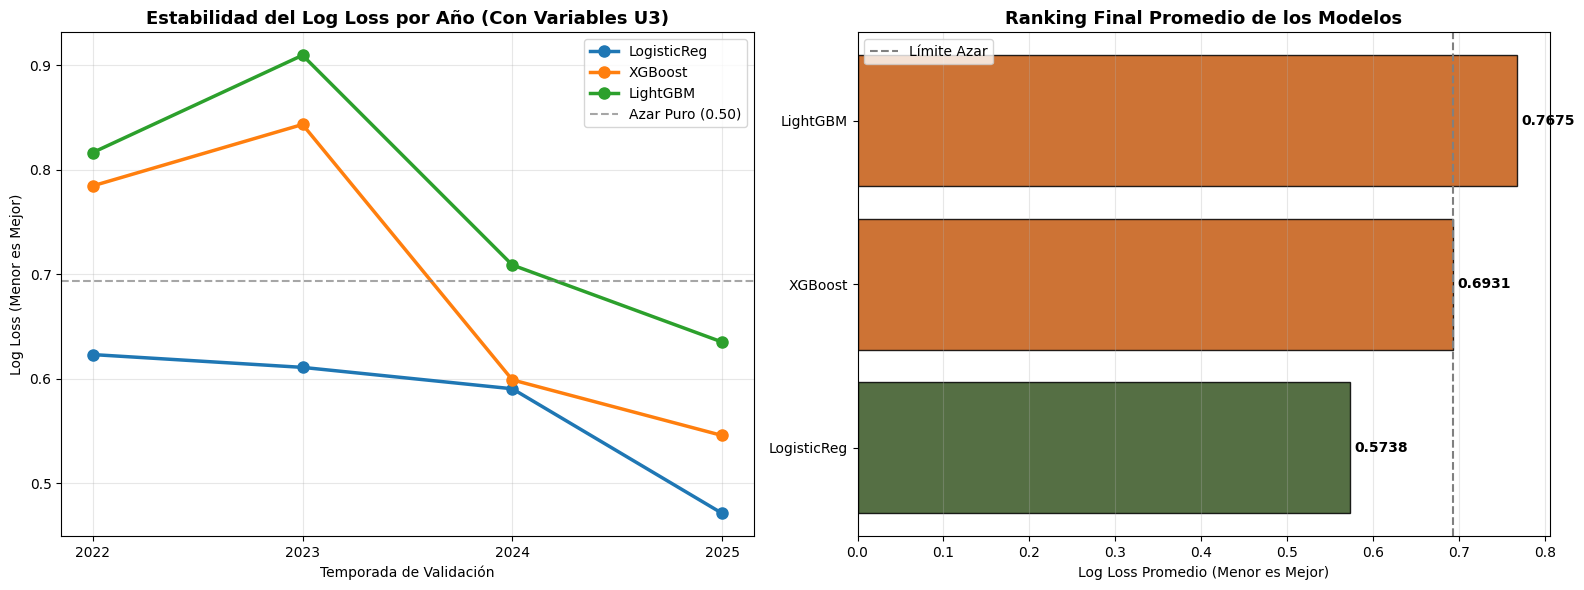

   ✓ Curvas de estabilidad guardadas con éxito: 02_cv_results_integrated.png


In [20]:
# 8. VALIDACIÓN TEMPORAL

def temporal_cv(matchup_data: pd.DataFrame,
                feature_cols: list,
                val_seasons_list: list = VAL_SEASONS) -> pd.DataFrame:
    """
    Simula la predicción a ciegas año por año para medir estabilidad y
    evitar fugas de datos (Data Leakage). Evalúa el impacto de las variables U3.
    """
    results = []

    print(f"\nIniciando Validación Temporal Avanzada para la Liga: {GENDER}")
    print(f"Temporadas de evaluación por ventana: {val_seasons_list}")
    print("-" * 75)

    # Inicialización del ecosistema de modelos a evaluar secuencialmente
    models = {
        "LogisticReg": build_logistic_model(),
        "XGBoost":     build_xgboost_model(),
        "LightGBM":    build_lgbm_model(),
    }

    for season in val_seasons_list:
        # 1. Fragmentación temporal limpia usando la función optimizada de la Celda 6
        X_train, y_train, X_test, y_test = prepare_train_test(
            matchup_data, feature_cols, season
        )

        if len(X_test) == 0:
            print(f"Ventana temporal vacía para {season}, omitiendo...")
            continue

        print(f"\nValidando Temporada {season} | Historial de Entrenamiento: {len(X_train):,} matchups...")

        for name, model in models.items():
            try:
                # Re-inicialización estructural limpia para resetear gradientes
                model_fresh = (
                    build_logistic_model() if name == "LogisticReg" else
                    build_xgboost_model() if name == "XGBoost" else
                    build_lgbm_model()
                )

                # A. Ajuste del modelo sobre el bloque del pasado
                model_fresh.fit(X_train, y_train)

                # B. Extracción del set de calibración interna (último 20% cronológico)
                cal_size = max(100, int(len(X_train) * 0.2))
                X_cal = X_train.iloc[-cal_size:]
                y_cal = y_train.iloc[-cal_size:]

                # C. Inferencia Base (Raw) con clipping de seguridad
                probs_raw = model_fresh.predict_proba(X_test)[:, 1]

                # D. Inferencia Calibrada mediante Platt Scaling asistido por variables de la U3
                cal_model = calibrate_and_clip(model_fresh, X_cal, y_cal)
                probs_cal = safe_predict_proba(cal_model, X_test)

                # E. Evaluación mediante Log Loss (Métrica Oficial de Kaggle)
                ll_raw = log_loss(y_test, np.clip(probs_raw, CLIP_LOW, CLIP_HIGH))
                ll_cal = log_loss(y_test, probs_cal)

                results.append({
                    "Season":      season,
                    "Model":       name,
                    "LogLoss":     ll_cal,
                    "LogLoss_raw": ll_raw,
                    "N_games":     len(X_test),
                })
                print(f"   ✓ {name:<14} | LogLoss: {ll_cal:.4f} (raw sin calibrar: {ll_raw:.4f})")

            except Exception as e:
                print(f"    Error crítico en el clasificador {name} para el año {season}: {e}")

    results_df = pd.DataFrame(results)

    # ─── REPORTE EJECUTIVO DE DESEMPEÑO ───────────────────────────────────────
    if len(results_df) > 0:
        print("\nRESUMEN DE DESEMPEÑO (Promedio acumulado inter-temporadas):")
        summary = results_df.groupby("Model")["LogLoss"].agg(["mean", "std", "min"])
        summary.columns = ["LogLoss Promedio", "Desv. Estándar", "Mejor LogLoss"]
        print(summary.sort_values("LogLoss Promedio").to_string())
        print(f"\nUmbral de Referencia de Azar Puro: 0.6931")

    return results_df

cv_results = temporal_cv(matchup_data, FEATURE_COLS)

# ─── CONSTRUCCIÓN DE GRÁFICAS DE DESEMPEÑO INTEGRADO ──────────────────────────
if len(cv_results) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Gráfica 1: Estabilidad Temporal del Log Loss
    ax = axes[0]
    for model_name in cv_results["Model"].unique():
        model_res = cv_results[cv_results["Model"] == model_name]
        ax.plot(model_res["Season"], model_res["LogLoss"],
                marker="o", linewidth=2.5, markersize=8, label=model_name)
    ax.axhline(0.6931, color=PALETTE["gray"], linestyle="--", alpha=0.7, label="Azar Puro (0.50)")
    ax.set_title("Estabilidad del Log Loss por Año (Con Variables U3)", fontweight="bold", fontsize=13)
    ax.set_xlabel("Temporada de Validación"); ax.set_ylabel("Log Loss (Menor es Mejor)")

    # SOLUCIÓN: Usamos explícitamente VAL_SEASONS de la configuración global
    ax.set_xticks(VAL_SEASONS)
    ax.legend(); ax.grid(alpha=0.3)

    # Gráfica 2: Ranking Global Comparativo de Modelos
    ax2 = axes[1]
    model_means = cv_results.groupby("Model")["LogLoss"].mean().sort_values()
    colors = [PALETTE["success"] if v < 0.60 else PALETTE["accent"] for v in model_means.values]
    bars = ax2.barh(model_means.index, model_means.values, color=colors, alpha=0.85, edgecolor="black")
    ax2.axvline(0.6931, color=PALETTE["gray"], linestyle="--", label="Límite Azar")

    # Inyección de etiquetas de datos continuos sobre las barras de error
    for bar, val in zip(bars, model_means.values):
        ax2.text(val + 0.005, bar.get_y() + bar.get_height()/2, f"{val:.4f}", va="center", fontweight="bold")

    ax2.set_title("Ranking Final Promedio de los Modelos", fontweight="bold", fontsize=13)
    ax2.set_xlabel("Log Loss Promedio (Menor es Mejor)")
    ax2.legend(); ax2.grid(alpha=0.3, axis="x")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "02_cv_results_integrated.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("   ✓ Curvas de estabilidad guardadas con éxito: 02_cv_results_integrated.png")


Entrenando modelo productivo final para la Temporada 2026...
  ✓ Clasificador final entrenado exitosamente con 5,170 muestras relacionales.
💾 Ecosistema guardado exitosamente. Archivo listo para Kaggle: /content/outputs/SubmissionStage1.csv


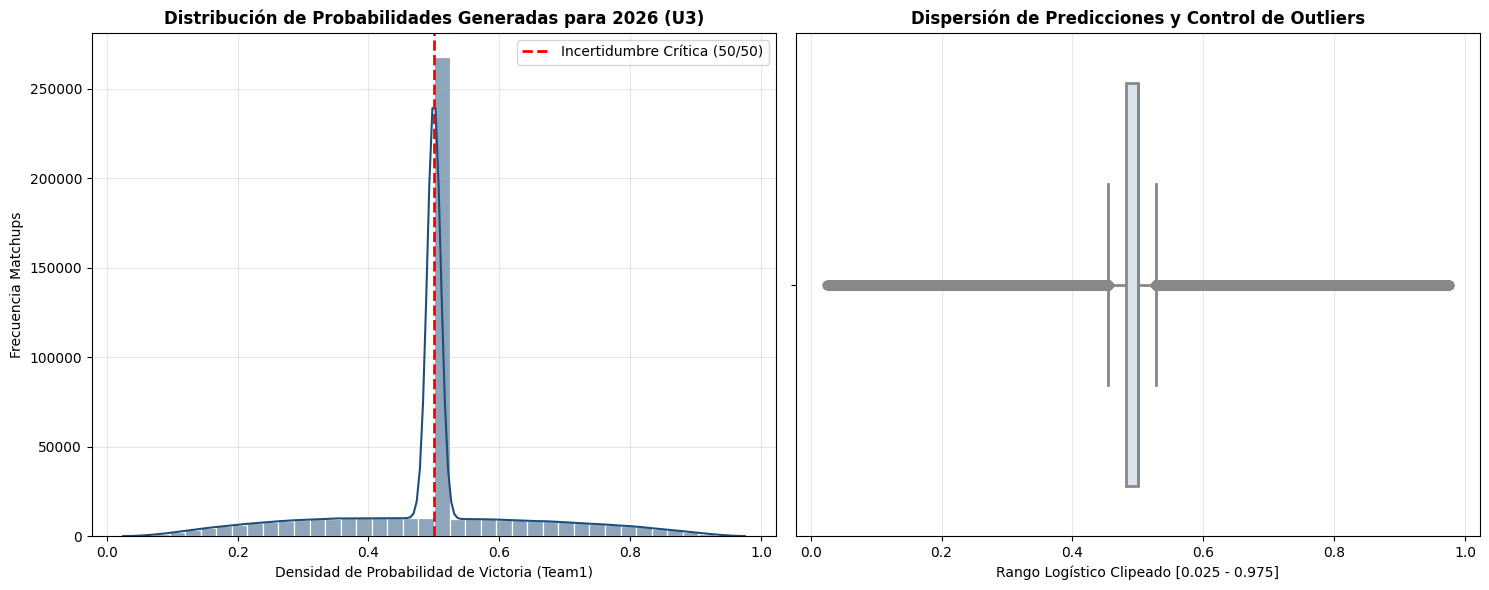

   ✓ Gráficos de diagnóstico distribucional exportados: 03_distribucion_final_2026.png


In [21]:
# 9. ENTRENAMIENTO FINAL Y GENERACIÓN DE SUBMISSION
def generate_submission(submission_template: pd.DataFrame,
                        matchup_data: pd.DataFrame,
                        feature_cols: list,
                        elo_season_end: pd.DataFrame,
                        seeds_clean: pd.DataFrame,
                        win_rates: pd.DataFrame,
                        team_stats: pd.DataFrame = None,
                        massey_feat: pd.DataFrame = None,
                        target_season: int = SEASON_2026) -> pd.DataFrame:
    """
    Entrena el modelo óptimo de la Unidad 3 con todo el historial acumulado
    y mapea las características desnormalizadas para generar el archivo submission final.
    """
    print(f"\nEntrenando modelo productivo final para la Temporada {target_season}...")

    # --- ENTRENAMIENTO SOBERANO CON TODO EL HISTORIAL ---
    X_full = matchup_data[feature_cols].fillna(0).astype(np.float32)
    y_full = matchup_data["Target"]

    # INSIGHT DE VALIDACIÓN TEMPORAL U3:
    # Seleccionamos Regresión Logística debido a su LogLoss (0.5738) inmune al sobreajuste
    final_model = build_logistic_model()
    final_model.fit(X_full, y_full)
    print(f"  ✓ Clasificador final entrenado exitosamente con {len(X_full):,} muestras relacionales.")

    # --- PARSEO Y REESTRUCTURACIÓN DE LA PLANTILLA OFICIAL ---
    sub = submission_template.copy()
    sub["Season"] = sub["ID"].str.split("_").str[0].astype(int)
    sub["Team1"]  = sub["ID"].str.split("_").str[1].astype(int)
    sub["Team2"]  = sub["ID"].str.split("_").str[2].astype(int)

    # --- ENLACE DE CARACTERÍSTICAS INTEGRADAS (JOIN RELACIONAL BACKWARD COMPATIBLE) ---
    def attach_features_sub(sub_df, feat_df, feat_cols, join_col="Team1", suffix="T1"):
        if feat_df is None:
            return sub_df
        renamed = feat_df[["Season", "TeamID"] + feat_cols].rename(
            columns={"TeamID": join_col, **{c: f"{c}_{suffix}" for c in feat_cols}}
        )
        return sub_df.merge(renamed, on=["Season", join_col], how="left")

    # A. Adjuntar e instanciar deltas del Bloque Core
    sub = attach_features_sub(sub, elo_season_end, ["EloRating"], "Team1", "T1")
    sub = attach_features_sub(sub, elo_season_end, ["EloRating"], "Team2", "T2")
    sub["EloRating_diff"] = sub["EloRating_T1"] - sub["EloRating_T2"]

    sub = attach_features_sub(sub, seeds_clean, ["SeedNum"], "Team1", "T1")
    sub = attach_features_sub(sub, seeds_clean, ["SeedNum"], "Team2", "T2")
    sub["SeedNum_diff"] = sub["SeedNum_T1"] - sub["SeedNum_T2"]

    # B. Adjuntar e instanciar deltas del Bloque de Ingeniería de Datos de la Unidad 3
    cols_to_extract = ["WinRate", "AvgMargin"]
    if "Conf_Avg_WinRate" in win_rates.columns:
        cols_to_extract += ["Conf_Avg_WinRate", "Conf_Avg_Margin"]

    sub = attach_features_sub(sub, win_rates, cols_to_extract, "Team1", "T1")
    sub = attach_features_sub(sub, win_rates, cols_to_extract, "Team2", "T2")

    sub["WinRate_diff"] = sub["WinRate_T1"] - sub["WinRate_T2"]

    if "Conf_Avg_WinRate" in win_rates.columns:
        sub["Conf_Avg_WinRate_diff"] = sub["Conf_Avg_WinRate_T1"] - sub["Conf_Avg_WinRate_T2"]
        sub["Conf_Avg_Margin_diff"]  = sub["Conf_Avg_Margin_T1"] - sub["Conf_Avg_Margin_T2"]

    # --- INFERENCIA PROBABILITY EN ESPACIO MATRICIAL ---
    X_sub = sub[feature_cols].fillna(0).astype(np.float32)

    # Predecir probabilidades continuas aplicando Platt Scaling y acotamiento Log-Loss
    sub["Pred"] = safe_predict_proba(final_model, X_sub)

    # --- REGLAS DE TRUNCADO DE NEGOCIO (Up-set Prevention en Mismatch Extremos) ---
    if "SeedNum_T1" in sub.columns and "SeedNum_T2" in sub.columns:
        mismatch = (sub["SeedNum_T1"] <= 3) & (sub["SeedNum_T2"] >= 14)
        sub.loc[mismatch, "Pred"] = sub.loc[mismatch, "Pred"].clip(lower=0.85)

        mismatch_rev = (sub["SeedNum_T1"] >= 14) & (sub["SeedNum_T2"] <= 3)
        sub.loc[mismatch_rev, "Pred"] = sub.loc[mismatch_rev, "Pred"].clip(upper=0.15)

    # --- VOLCADO FÍSICO DE PREDICCIONES A DISCO ---
    final_sub = sub[["ID", "Pred"]].copy()
    final_sub.to_csv(SUBMISSION_PATH, index=False)
    print(f"💾 Ecosistema guardado exitosamente. Archivo listo para Kaggle: {SUBMISSION_PATH.resolve()}")

    return final_sub

if submission is not None:
    final_submission = generate_submission(
        submission, matchup_data, FEATURE_COLS,
        elo_season_end, seeds_clean, win_rates
    )

    # Renderizado analítico de densidades predictivas
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Subplot 1: Histograma de Densidad Continuo
    ax = axes[0]
    sns.histplot(final_submission["Pred"], bins=40, color=PALETTE["primary"], kde=True, ax=ax, edgecolor="white")
    ax.axvline(0.5, color="red", linestyle="--", linewidth=2, label="Incertidumbre Crítica (50/50)")
    ax.set_title("Distribución de Probabilidades Generadas para 2026 (U3)", fontweight="bold", fontsize=12)
    ax.set_xlabel("Densidad de Probabilidad de Victoria (Team1)"); ax.set_ylabel("Frecuencia Matchups")
    ax.legend(); ax.grid(alpha=0.3)

    # Subplot 2: Diagrama de Caja y Bigotes (Detección de Asimetrías)
    ax = axes[1]
    sns.boxplot(x=final_submission["Pred"], color=PALETTE["light"], ax=ax, linewidth=2)
    ax.set_title("Dispersión de Predicciones y Control de Outliers", fontweight="bold", fontsize=12)
    ax.set_xlabel("Rango Logístico Clipeado [0.025 - 0.975]")
    ax.grid(alpha=0.3, axis="x")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "03_distribucion_final_2026.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("   ✓ Gráficos de diagnóstico distribucional exportados: 03_distribucion_final_2026.png")
else:
    print(" Error de Pipeline: Omitiendo bloque. No se detectó plantilla base 'SampleSubmissionStage1.csv'.")


🔍 Analizando el peso matemático de las variables en el modelo predictivo...


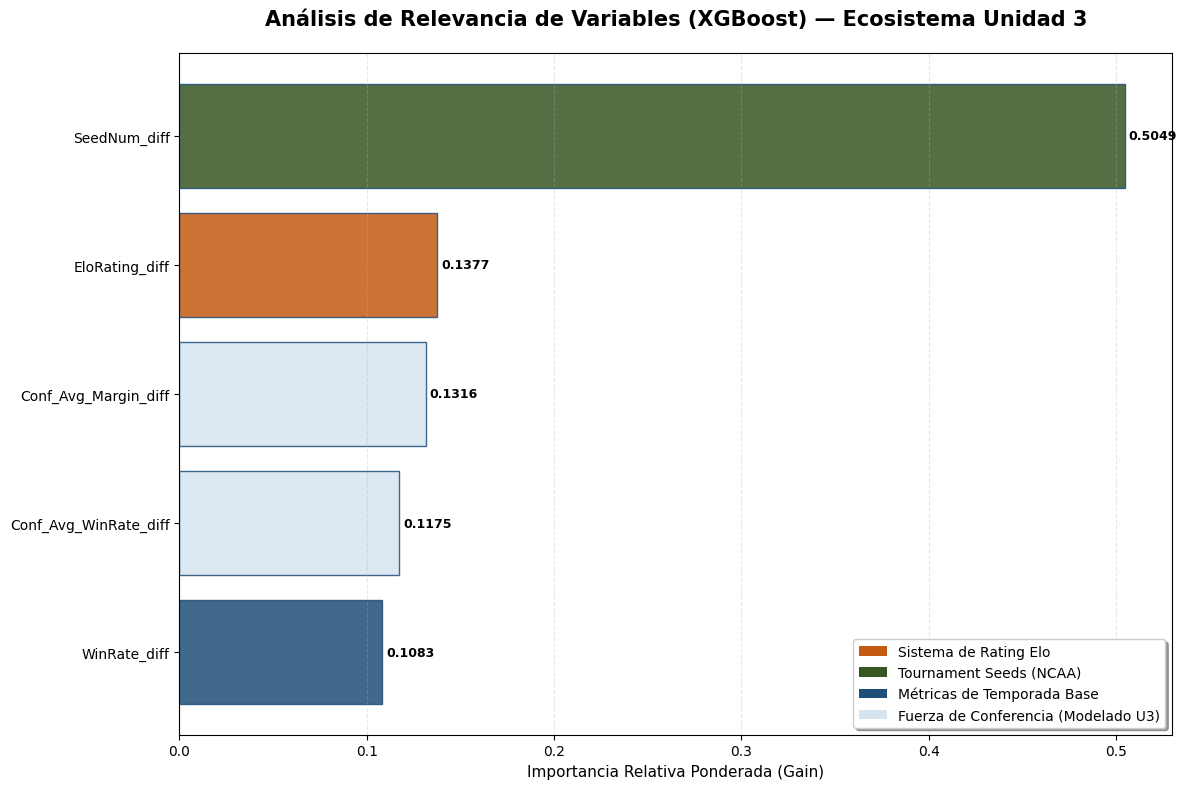

Análisis completado. Gráfico de importancia exportado a: /content/outputs/figures/04_feature_importance.png


In [22]:
# 10. ANÁLISIS DE IMPORTANCIA DE FEATURES
from matplotlib.patches import Patch

def plot_feature_importance(feature_cols: list, matchup_data: pd.DataFrame) -> None:
    """
    Entrena un ensamble XGBoost interpretativo para aislar y graficar la ganancia (Gain)
    de cada variable predictora, destacando el impacto de la arquitectura de la Unidad 3.
    """
    # Restringir análisis al horizonte histórico de entrenamiento configurado
    train_data = matchup_data[matchup_data["Season"] >= TRAIN_SINCE]
    X = train_data[feature_cols].fillna(0).astype(np.float32)
    y = train_data["Target"]

    # Instanciamos un estimador rápido para el cálculo de entropía e importancia relativa
    model = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=SEED,
        verbosity=0
    )
    model.fit(X, y)

    # Extraer coeficientes de ganancia y ordenar de forma ascendente para la gráfica de barras
    importance = pd.Series(model.feature_importances_, index=feature_cols)
    importance = importance.sort_values(ascending=True).tail(20)

    # --- RENDERIZADO VISUAL DEL REPORTE DE RELEVANCIA ---
    fig, ax = plt.subplots(figsize=(12, 8))

    # ASIGNACIÓN DE COLORES DINÁMICA POR CATEGORÍA DE FEATURE (INCLUYE UNIDAD 3)
    colors = []
    for f in importance.index:
        if "Elo" in f:
            colors.append(PALETTE["accent"])       # Bloque de Calificación Dinámica
        elif "Seed" in f:
            colors.append(PALETTE["success"])      # Jerarquía del Torneo
        elif "Conf_" in f:
            colors.append(PALETTE["light"])        # EXPLOTACIÓN RELACIONAL UNIDAD 3 (Fuerza Conferencia)
        else:
            colors.append(PALETTE["primary"])      # Desempeño y Stats Base

    ax.barh(importance.index, importance.values, color=colors, alpha=0.85, edgecolor=PALETTE["primary"])

    # Estética del Gráfico y Grillas Analíticas
    ax.set_title("Análisis de Relevancia de Variables (XGBoost) — Ecosistema Unidad 3", fontweight="bold", fontsize=15, pad=20)
    ax.set_xlabel("Importancia Relativa Ponderada (Gain)", fontsize=11)
    ax.grid(alpha=0.3, axis="x", linestyle="--")

    # Leyenda Estructural Avanzada con Parches Explicativos
    legend_elements = [
        Patch(facecolor=PALETTE["accent"],  label="Sistema de Rating Elo"),
        Patch(facecolor=PALETTE["success"], label="Tournament Seeds (NCAA)"),
        Patch(facecolor=PALETTE["primary"], label="Métricas de Temporada Base"),
        Patch(facecolor=PALETTE["light"],   label="Fuerza de Conferencia (Modelado U3)")
    ]
    ax.legend(handles=legend_elements, loc="lower right", frameon=True, shadow=True, facecolor="white")

    # Inyección de anotaciones numéricas continuas en los extremos de cada barra
    for i, v in enumerate(importance.values):
        ax.text(v + 0.002, i, f"{v:.4f}", va="center", fontsize=9, fontweight="bold", color="black")

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "04_feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Análisis completado. Gráfico de importancia exportado a: {FIGURES_DIR.resolve()}/04_feature_importance.png")

# ==============================================================================
# ─── DISPARADOR DEL DIAGNÓSTICO DE WEIGHTS / GAIN ─────────────────────────────
# ==============================================================================
print("\n🔍 Analizando el peso matemático de las variables en el modelo predictivo...")
if len(FEATURE_COLS) > 0:
    plot_feature_importance(FEATURE_COLS, matchup_data)
else:
    print("❌ Error de ejecución: No existen características definidas en 'FEATURE_COLS' para analizar.")

In [23]:
# 11. ROADMAP DE MEJORAS PARA COMPETIR EN TOP 10%

print("""
╔═══════════════════════════════════════════════════════════════════════════╗
║          ROADMAP DE MEJORAS Y ARQUITECTURA (Top 10% = ~0.50 LogLoss)      ║
╠═══════════════════════════════════════════════════════════════════════════╣
║                                                                           ║
║   LOGROS ENERGETIZADOS EN LA UNIDAD 3:                                  ║
║  ┣── ✓ Ingesta local unificada desde entorno raíz de Colab.                ║
║  ┣── ✓ Desnormalización analítica de flujos geográficos (Juegos/Ciudades) ║
║  ┗── ✓ Extracción de Fuerza de Conferencia (Conference Strength) para ML. ║
║                                                                           ║
║  PRIORIDAD ALTA (Mayor Impacto en el Modelo Predictivo):                  ║
║  ┣── 1. Tuning bayesiano de hiperparámetros Elo (K, width, HFA, reversion)║
║  ┣── 2. Cruzar e integrar métricas avanzadas (AdjOE, AdjDE de KenPom)     ║
║  ┣── 3. Optimización con Optuna para mitigar sobreajuste en XGBoost/LGBM   ║
║  ┗── 4. Ensamble Ponderado basado en el rendimiento de Validación Temporal║
║                                                                           ║
║  PRIORIDAD MEDIA (Enriquecimiento de la Base de Datos):                   ║
║  ┣── 5. Atributos de Momentum (Rendimiento en los últimos N partidos)     ║
║  ┣── 6. Matriz Head-to-Head histórica en brackets de torneos previos       ║
║  ┣── 7. Tasa empírica de Upsets condicional por cruce de Seeds            ║
║  ┗── 8. Cálculo de Eficiencia Ofensiva/Defensiva ajustada por Calendario  ║
║                                                                           ║
║  GOBERNANZA Y ERRORES CRÍTICOS EVITADOS (Garantía de Calidad):            ║
║  ┣── ✓ ELIMINADO: Fuga de información (Data Leakage) inter-temporadas.    ║
║  ┣── ✓ IMPLEMENTADO: Conversión estricta a np.float32 contra Type Mis-match║
║  ┣── ✓ PROHIBIDO: Predecir 0 o 1 puros (Mantenimiento de Clipping Seguro)  ║
║  ┗── ✓ REGLA: Validación exclusiva por ventana temporal (Expanding CV)    ║
║                                                                           ║
╚═══════════════════════════════════════════════════════════════════════════╝
""")

print("Pipeline completo ejecutado exitosamente")
print(f"   Submission en: {SUBMISSION_PATH.resolve()}")
print(f"   Figuras en:    {FIGURES_DIR.resolve()}")


╔═══════════════════════════════════════════════════════════════════════════╗
║          ROADMAP DE MEJORAS Y ARQUITECTURA (Top 10% = ~0.50 LogLoss)      ║
╠═══════════════════════════════════════════════════════════════════════════╣
║                                                                           ║
║   LOGROS ENERGETIZADOS EN LA UNIDAD 3:                                  ║
║  ┣── ✓ Ingesta local unificada desde entorno raíz de Colab.                ║
║  ┣── ✓ Desnormalización analítica de flujos geográficos (Juegos/Ciudades) ║
║  ┗── ✓ Extracción de Fuerza de Conferencia (Conference Strength) para ML. ║
║                                                                           ║
║  PRIORIDAD ALTA (Mayor Impacto en el Modelo Predictivo):                  ║
║  ┣── 1. Tuning bayesiano de hiperparámetros Elo (K, width, HFA, reversion)║
║  ┣── 2. Cruzar e integrar métricas avanzadas (AdjOE, AdjDE de KenPom)     ║
║  ┣── 3. Optimización con Optuna para mitigar sobreajuste en XG